![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Agnostic Interpretation with LIME

In this Notebook, we will demonstrate how to use the Local Interpretable Model-Agnostic Explanations (LIME) method ([Rubiero et. al., 2016](https://doi.org/10.1145/2939672.2939778)) and interpret its results.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-random-forest/Gen-2-Tutorial_LIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-random-forest.txt
# %cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LinearRegression, Ridge # used as surrogate model for LIME

import warnings
warnings.filterwarnings('ignore')

Now, we fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [2]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

--------

## Data and Model Loading: The California Housing Dataset

In this notebook, we will work with the **California Housing dataset**, containing 20,640 median house values for California districts (expressed in $100,000), which are described by 8 numeric feature. Each row in the dataset represents a block of houses, not a single household. The data pertains to the house prices found in a given California district and some summary statistics about them based on the 1990 census data. Our goal is to **predict price** of house blocks and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_california_housing.jpg?raw=true" width="900" /></center>

<font size=1> Source: [Link](https://www.kaggle.com/datasets/harrywang/housing)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook is the interpretation of the previously trained model.

In [3]:
# Load and unpack the data
with open('../models/model_rf_housing.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)

X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_housing = data_and_model[4]

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_housing.score(X_train, y_train),2)} R^2.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_housing.score(X_test, y_test),2)} R^2.')

Model Performance on training data: 0.84 R^2.
Model Performance on test data: 0.72 R^2.


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

*Note: The $R^2$ is the coefficient of determination, and the closer this value is to 1, the better our model explains the data. A constant model that always predicts the average target value disregarding the input features would get an $R^2$ score of 0. However, the $R^2$ score can also be negative because the model can be arbitrarily worse.*

## Now, what does my model think is important in the data?

### Local Interpretable Model-Agnostic Explanations (LIME)

**We prepared a small [Introduction to LIME](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html) for you, to help you understand how this method works.**

*Note: we provide all references [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html#references).*

<font color='green'>

#### Question 1: What is a surrogate model?

<font color='grey'>

#### Your Answer: 
It’s an interpretable model, such as linear or tree models, that approximates the prediction of a more complex model.


<font color='green'>

#### Question 2: How is LIME using surrogate models to explain a model prediction?

<font color='grey'>

#### Your Answer: 
It randomly samples data points in the neighbourhood of the sample point and lets the complex model make predictions for those points. This data set is then used to fit a surrogate model which can than be analysed to identify important features.

Now let's use LIME to get some insights into the Random Forest Regression model we loaded above. We first have to specify an important parameter for LIME: the *kernel_width*, which, in principle, determines how large the neighborhood around our sample will be. The optimal choice of this parameter is difficult and currently still an open research question and one of the main disadvantages of the method. Feel free to play around with different values and observe how the generated explanations can change.

*Note: this method is a local method, which means that it only provides explanations for individual samples but not for a full dataset.*

In [4]:
kernel_width = 1 # default is 0.75 * sqrt(n_features)

In [5]:
explainer = LimeTabularExplainer(
    training_data=X_train, # the data was standardized beforehand during training of the RF model
    mode="regression",
    training_labels=y_train,
    feature_names=X_train.columns,
    feature_selection='none',  # before applying the surrogate model, one could also select features
    random_state=seed,
    sample_around_instance=True,  # default: mean value of the training data; however, can be set the instance itself to generate samples similar to our instance with high probability
    kernel_width=kernel_width,  
    discretize_continuous=False 
)

Once we have defined the setup for LIME, we have to choose an instance of interest for which we want to get explanations, the neighborhood size, i.e. number of points we want to sample in the neighborhood of our instance of interest to build the surrogate model, and the type of surrogate model. The size of the neighborhood should be chosen large enough because the surrogate model needs a sufficient number of data points for training. As a surrogate model, we choose the Linear Regression model because the coefficients of a linear model allow an intrinsic interpretation of the model.

*Note: when you are using a linear model as a surrogate model, you have to ensure that the input data is properly standardized beforehand. Our data was standardized before training the Random Forest model.*

In [6]:
# NOTE: LIME expects as input a numpy array. Hence, we convert all data frames to numpy arrays
X_train_array = X_train.to_numpy()
y_train_array = y_train.to_numpy()

In [7]:
# choose an instance that you want to explain
inst_idx = 0

print(f"Instance {inst_idx} of training data will be explained.")

# number of samples in the neighborhood of our point that we will use to fit
# a simpler surrogate model to explain the original complex models predictions
num_samples = 5000

instance = X_train_array[inst_idx]
instance_label = y_train_array[inst_idx]

explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=model_housing.predict, # prediction method of model that I want to explain
    labels=instance_label,
    model_regressor=LinearRegression(), # surrogate model
    num_samples=num_samples, # size of the neighborhood
)

Instance 0 of training data will be explained.


All that LIME did was to fit a linear regression model to approximate the complex model's predictions, i.e., the predictions of the Random Forest model. The dataset for creating the fit consists of the neighborhood samples that were randomly created around our selected instance. 

Linear regression models estimate a single parameter (coefficient) for each feature. Those coefficients describe the mathematical relationship between each feature (independent variable) and the target (dependent variable). The sign of a linear regression coefficient tells you whether there is a positive or negative correlation between the feature and the target. The coefficient value signifies how much the mean of the target changes given a one-unit shift in the feature while holding other features in the model constant. Hence, we can plot the coefficients of the Linear Regression Surrogate model to understand which features are most predictive for our instance of interest.

*Note: LIME is not restricted to linear regression models; other easy-to-interpret surrogate models could be used like decision trees.*

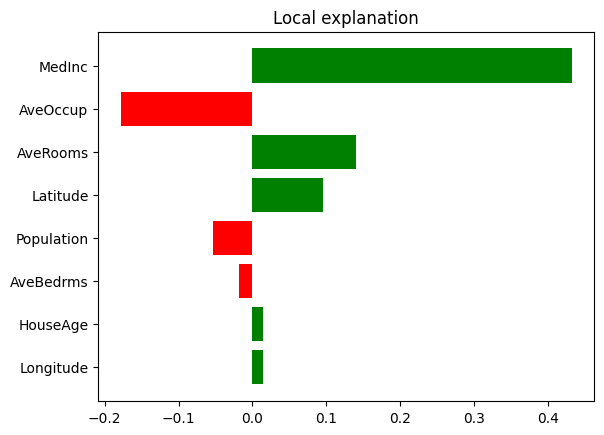

In [8]:
explanation.as_pyplot_figure(); # semicolon added because as_pyplot_figure displays and returns the figure, which in turn gets displayed by jupyter if you don't assign it to anything.

Two of the most informative features for the model are the *median income* (MedInc) and *average occupancy* (AveOccup), which are the features with the highest absolute model coefficients. The positive sign of the *median income* coefficient indicates a positive relation between this feature and the target variable (*price*), i.e., a higher income leads to higher price predictions. On the other hand, the negative sign of the *average occupancy* coefficient suggests that as the occupancy (i.e., more people living in the house block) increases, the price tends to decrease.  

To measure how well the simpler surrogate model is able to approximate the predictions of the more complex model, we can use any metric that summarizes the quality of the predictions that the surrogate model makes. This chosen metric can serve as a "fidelity measure", which indicates how reliable the interpretable model is. Even though the choice of the fidelity measure is up to you, it is important to assess the predictive ability of the surrogate model when LIME explanations are to be used!

How much would you trust explanations delivered from a surrogate model that can not reasonably approximate the complex model's predictions?

In our case, we used a linear regression model as a surrogate model. A commonly used metric to quantify the goodness of fit for the linear regression model is the $R^2$ score. It shows how well the linear model is able to approximate the predictions of the more complex model on the neighborhood samples. $R^2$ scores closer to 1 indicate better approximations. Our surrogate model achieves an $R^2$ score of ~ 0.8, indicating that the explanations given by that model can be trusted.

In [9]:
explanation.score

0.8106404788837749

<font color='green'>

#### Question 3: What are the main differences to Permutation Feature Importance?

<font color='grey'>

#### Your Answer: 
LIME is purely local and can only explain one instance at a time.

--------

<font color='green'>

### Task: Apply LIME to the Wine Dataset

In this exercise, you will apply **LIME (Local Interpretable Model-Agnostic Explanations)** to the trained Random Forest classifier in order to understand how different chemical properties influence individual wine classification predictions.

Your task is to:

1. Create an appropriate LIME explainer for the wine dataset.
2. Generate LIME explanations for individual wine samples from different wine classes.
3. Visualize and interpret the local feature contributions for the selected samples.
4. Compare the explanations between different wine classes and individual observations.
5. Investigate how the local feature importance changes for correctly and incorrectly classified samples.
6. Experiment with different LIME parameters, such as the number of generated neighborhood samples (`num_samples`), the kernel width (`kernel_width`), or the choice of the surrogate model, and analyze how these settings influence the stability and interpretability of the explanations.

> **Hint:** In contrast to global explanation methods such as Permutation Feature Importance, LIME provides local explanations for individual predictions. The resulting feature importance scores therefore depend on the selected wine sample.

> **Hint:** The standard `LimeTabularExplainer` implementation is designed around linear surrogate models and therefore expects interpretable models with coefficients (e.g. linear regression or ridge regression). While nonlinear surrogate models such as decision trees could theoretically be used for local approximation, they are not directly supported by the default tabular LIME implementation.

> **Hint:** Compare the local LIME explanations with the global feature importance patterns observed previously. Features that are globally important are not necessarily equally important for every individual wine sample.


**The Wine dataset**

Let's use the wine quality dataset to see how XAI can be used to explain multi-class classification models. The **Wine Recognition dataset** contains 178 wine samples from three different cultivators of wine in the same region in Italy. The wine was chemically analyzed and 13 different chemical attributes like *alcohol*, *malic acid*, *flavanoids* etc were measured. Our goal is to **classify wines** and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_red_wine.jpg?raw=true" width="900" /></center>

<font size=1> Source:
[Link](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook lies on the interpretation of the previously trained model.

In [10]:
# Load and unpack the data
with open('../models/model_rf_wine.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)
    
X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_wine = data_and_model[4]

X_train.head()

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_wine.score(X_train, y_train)*100,2)} % accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_wine.score(X_test, y_test)*100,2)} % accuracy.')

Model Performance on training data: 100.0 % accuracy.
Model Performance on test data: 97.22 % accuracy.


As shown by the metrics above, the model achieves perfect performance on the training set while also generalizing very well to the independent test set.

**Understanding Local Feature Contributions in the Wine Dataset**

We can now apply LIME to better understand how the trained model uses the different chemical properties to make predictions for individual wine samples and distinguish between the three wine classes.


In [11]:
X_train_array = X_train.to_numpy()
y_train_array = y_train.to_numpy()

In [12]:
explainer = LimeTabularExplainer(
    training_data=X_train, # the data was standardized beforehand during training of the RF model
    mode="classification",
    training_labels=y_train,
    feature_names=X_train.columns,
    feature_selection='none',  
    random_state=seed,
    sample_around_instance=True, 
    kernel_width=0.75 * np.sqrt(13),  
    discretize_continuous=False 
)

Instance 4 with true class type_1 is explained for predicted class 0. The surrogate model score is 0.55.


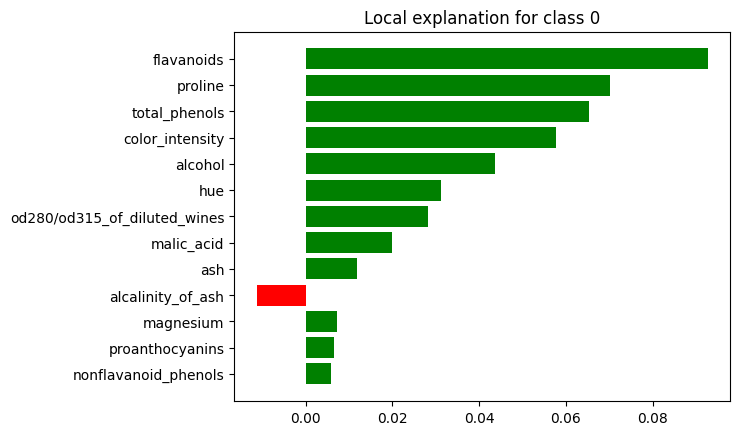

In [13]:
# choose an instance that you want to explain
inst_idx = 4
instance = X_train_array[inst_idx]
instance_label = y_train_array[inst_idx]

# generate LIME explanation
explanation = explainer.explain_instance(
    data_row=instance,  # instance to explain
    predict_fn=model_wine.predict_proba,  # probability predictions
    top_labels=1,  # explain highest predicted class
    model_regressor=Ridge(alpha=3, random_state=seed),  # local surrogate model
    num_samples=5000,  # perturbed neighborhood samples
)

# get the actually explained class
explained_label = explanation.top_labels[0]

print(
    f"Instance {inst_idx} with true class {instance_label} "
    f"is explained for predicted class {explained_label}. "
    f"The surrogate model score is {explanation.score:.2f}."
)

# plot explanation
explanation.as_pyplot_figure(label=explained_label);

Instance 1 with true class type_2 is explained for predicted class 1. The surrogate model score is 0.68.


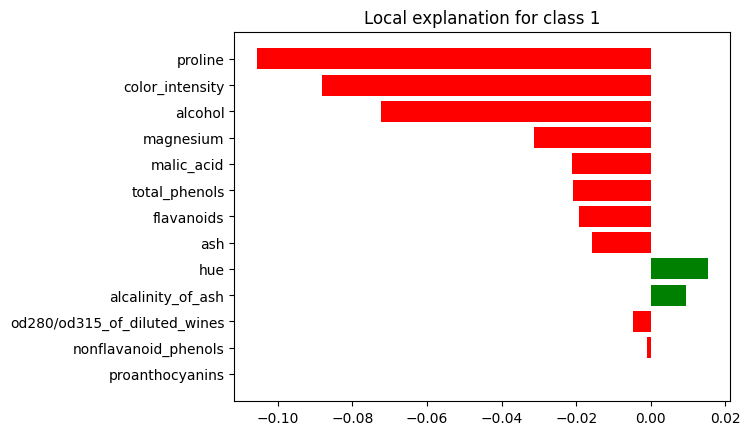

In [14]:
# choose an instance that you want to explain
inst_idx = 1
instance = X_train_array[inst_idx]
instance_label = y_train_array[inst_idx]

# generate LIME explanation
explanation = explainer.explain_instance(
    data_row=instance,  # instance to explain
    predict_fn=model_wine.predict_proba,  # probability predictions
    top_labels=1,  # explain highest predicted class
    model_regressor=Ridge(alpha=3, random_state=seed),  # local surrogate model
    num_samples=5000,  # perturbed neighborhood samples
)

# get the actually explained class
explained_label = explanation.top_labels[0]

print(
    f"Instance {inst_idx} with true class {instance_label} "
    f"is explained for predicted class {explained_label}. "
    f"The surrogate model score is {explanation.score:.2f}."
)

# plot explanation
explanation.as_pyplot_figure(label=explained_label);

Instance 101 with true class type_3 is explained for predicted class 2. The surrogate model score is 0.75.


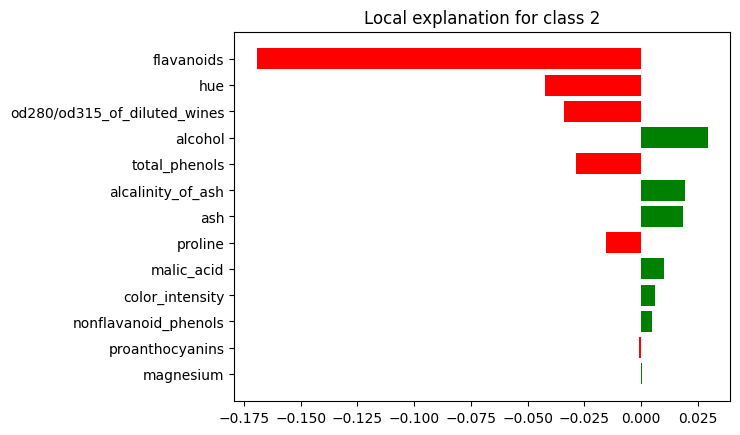

In [15]:
# choose an instance that you want to explain
inst_idx = 101

instance = X_train_array[inst_idx]
instance_label = y_train_array[inst_idx]

# generate LIME explanation
explanation = explainer.explain_instance(
    data_row=instance,  # instance to explain
    predict_fn=model_wine.predict_proba,  # probability predictions
    top_labels=1,  # explain highest predicted class
    model_regressor=Ridge(alpha=3, random_state=seed),  # local surrogate model
    num_samples=5000,  # perturbed neighborhood samples
)

# get the actually explained class
explained_label = explanation.top_labels[0]

print(
    f"Instance {inst_idx} with true class {instance_label} "
    f"is explained for predicted class {explained_label}. "
    f"The surrogate model score is {explanation.score:.2f}."
)

# plot explanation
explanation.as_pyplot_figure(label=explained_label);

**Conclusion**

The LIME explanations provide local insights into how the Random Forest model distinguishes between the three wine classes based on the chemical properties of individual wine samples. Although the globally important features already highlighted the relevance of variables such as *flavanoids*, *proline*, *alcohol*, and *color intensity*, the local explanations reveal that the importance and direction of these features vary substantially between individual predictions.

For the sample belonging to **class type_1**, features such as *flavanoids*, *proline*, and *total phenols* strongly support the prediction, while *alcalinity_of_ash* slightly decreases the model confidence. In contrast, the explanation for **class type_2** shows that high values of *proline*, *color intensity*, and *alcohol* negatively contribute to this class prediction, whereas features such as *hue* provide positive evidence. For the **class type_3** sample, the model mainly relies on negative contributions from *flavanoids*, *hue*, and *od280/od315_of_diluted_wines*, while features such as *alcohol* and *alcalinity_of_ash* increase the prediction confidence.

The surrogate model scores indicate how well the local linear approximation captures the behavior of the underlying Random Forest model around the selected sample. While the explanation for class type_3 achieves a reasonably good surrogate score of approximately 0.75, the scores for class type_1 (0.55) and class type_2 (0.68) are comparatively low. This suggests that the local linear surrogate only approximates the true model behavior moderately well in these regions of the feature space. Consequently, the corresponding LIME explanations should be interpreted with caution.

--------

## Extra Material: LIME computation step by step

To get a better understanding of LIME, we will now guide you step by step through the algorithm. Even though LIME offers an easy-to-use API, it can be beneficial to have a quick look behind the scenes to fully understand what is going on. LIME is especially suitable here since the basic algorithm can be programmed in just a few steps.

[Cristian Arteaga](https://nbviewer.org/urls/arteagac.github.io/blog/lime.ipynb) has also prepared a nice step-by-step explanation of LIME for a 2D toy problem and we recommend taking a look at his notebook which contains nice visualizations.
Here, we are focussing on tabular data, but Christian also provides a notebook that demonstrates how LIME can work on other modalities like images as well, which is one of its big strengths!

In [16]:
# Load and unpack the data
with open('../models/model_rf_housing.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)

X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_housing = data_and_model[4]

X_train_array = X_train.to_numpy()
y_train_array = y_train.to_numpy()

### Step 1
First, we select an instance for which we want to explain the prediction.
We generate many normally distributed random samples that will serve as our sample neighborhood.
The samples' expected value coincides with our instance to ensure sufficient similarity between the neighborhood and our instance, while the standard deviation is estimated from the training data.

Also note that we make our instance itself part of the neighborhood.

In [17]:
# select instance of interest
x = X_train_array[inst_idx]

# generate random perturbations around our selected instance
# with given mean and standard deviation
std = X_train_array.std(axis=0)

# NOTE: there are two options on setting the mean of the samples.
# The default in LIME is to set it to the mean value of the training data.
# However, it may be a better idea to set the mean to the instance itself
# (in LIME this is done by sample_around_instance=True) in order
# to generate samples similar to our instance with high probability.

#mu = X_train.mean(axis=0)
mu = x

neighbors_of_x = np.random.normal(mu, std, size=(num_samples, X_train_array.shape[1]))

# sneek in the instance itself as part of the neighbors
neighbors_of_x[0] = x

### Step 2
We let our original model predict the outcomes of the neighborhood samples.

In [18]:
# use the trained rf model to generate labels
neighbors_of_x_pred = model_housing.predict(neighbors_of_x)

### Step 3
We compute the distance of each neighbor to our instance and transform it to a weight which we will later use to fit our local surrogate model.
Note that distances are computed on standardized data in order to avoid numerical instabilities.

In [19]:
# compute euclidean distance of each neighbor to x 
# NOTE: distances are computed based on standardized data (including the instance of interest)
# the data we loaded was already standardized beforehand before training the RF model

distance_to_x = np.sum((neighbors_of_x - x)**2, axis=1)
weights = np.sqrt(np.exp(-1. * (distance_to_x / kernel_width)**2))

### Step 4
A surrogate model is fit to approximate the complex model's prediction on the neighborhood samples. We will use a linear regression model since that offers fairly straightforward explanations by looking at the estimated model coefficients. The fit will be performed again on the standardized samples!

The weights computed above will serve to indicate their importance to the fit. Models with large weights are closer to our instance and should get predicted more accurately than neighbors further apart from our instance.

In [20]:
# fit an explainable model on the scaled data to approximate the predictions of the complex model
#    on the neighborhood samples
explainable_model = LinearRegression()
explainable_model.fit(
    neighbors_of_x, 
    neighbors_of_x_pred,
    sample_weight=weights)

score = explainable_model.score(neighbors_of_x, neighbors_of_x_pred, sample_weight=weights)
print("\nModel performance", score)


Model performance 0.7796619813788046


### Step 5
We visualize the model coefficients to obtain a similar explanation as the LIME API offers us.

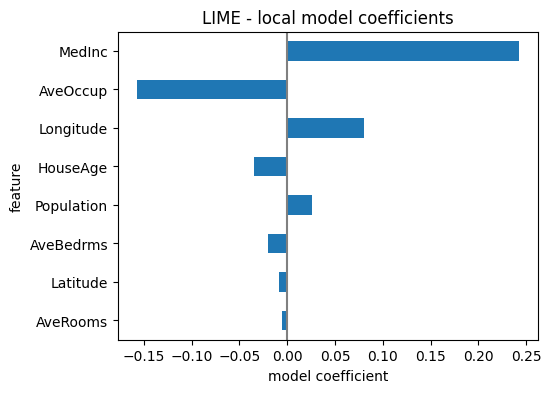

In [21]:
# get model coefficients
coef_dict = dict(zip(X_train.columns, explainable_model.coef_))
coef_dict_sorted = dict(sorted(coef_dict.items(), key=lambda x: np.abs(x[1]), reverse=False))
coef_df = pd.DataFrame.from_dict(coef_dict_sorted, columns=['model coefficient'], orient="index")

# plot similar as LIME provides
f, ax = plt.subplots(1, 1, figsize=(7, 4))
coef_df.plot(kind='barh', ax=ax)
plt.title('LIME - local model coefficients')
plt.xlabel('model coefficient')
plt.ylabel('feature')
plt.axvline(x=0, color='.5')
plt.subplots_adjust(left=.3)
_ = ax.set_yticklabels(coef_df.index)
ax.get_legend().remove()